In [4]:
import matplotlib.pyplot as plt
import re
import logging
import os
import numpy as np

Total Samples: 100
Correct Predictions: 49
Accuracy: 49.00%


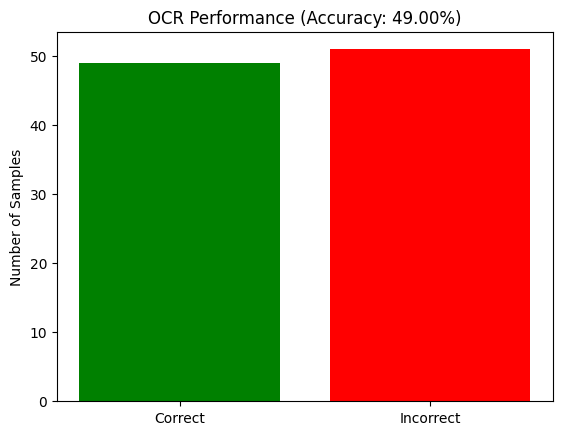

In [4]:
raw_data = """
BR01BZ3311:Y
JH01CW5150:JHO1CW515O
JH01ES8923:JH0TES8923
JH01FC0650:JH01FCO650
JH01BM1649:Y
JH10CY6835:JH1OCY6835
JH01CE5742:Y
JH01FL7162:Y
JH01CV8618:Y
JH01FX4952:JHO1FX4952
JH01AB7063:Y
JH01CJ6732:Y
JH01S5001:Y
BR1U8079:Y
JH01CW0499:Y
JH01EQ6934:JHO1EQ6934
JH01BL9208:Y
JH04E7208:Y
JH01CB0934:Y
JH01EQ6382:JHO1EQ6382
JH01DY5433:Y
JH01FC0394:JHO1FCO394
DL8CU0892:Y
JH12M9465:Y
JH01DS2498:Y
JH01BW9821:Y
JH01DH9198:1H01DH9198
JH01EK4473:JHO1EK4473
JH01Z0G88:JH01Z0G88
BR01CN9008:Y
AP31D01595:Y
UP60AR6762:UP6OAR6762
DL14CC7320:DL14CC7320J
JH04R7320:JHO4R732O
OD02BW0148:0D02BW0148
JHO5BQ4793:JHO5BQ4793M
JH01V3346:UH01V3346
DL8CBA5638:DL8CBA5638
JH02BG1670:JHO2BG167O
JH01CJ6732:JH01CJ6732
UKO7BU0955:LUKO7BU0955
JH01ER4247:JH0TER4247Y
JH01BV8298:Y
UP32QP6429:Y
BR24AQ5849:Y
KA04MN6059:KAO4MN6O59
TS08FW3544:TSO8FW3544
JH02BE579:Y
Jh01FP1870:Y
JH70CC9397:Y
JH1OCC9297:JH10CC9397
JH01A0814:Y
CG30G4387:CGOG4387
JH01FG1445:JH01FG1445
OD14Z9356:Y
JH01ES7338:H01ES7338
DL12CB3478:Y
HR26DC8709:HRZ6DC87O9
MH20EE7602:Y
HR26DX6666:Y
GJ04EE6437:GJO4EE6437
UP85BW1000:Y
MH20EJ0364:MH20EJO364
TG109999:Y
MH14MC8285:MH14MC8ZB5
RJ192C1055:RJ192C1055
MH12BG7237:Y
RJ14NC9698:J14NC9698
DL1CE1602:Y
RJ14UN4169:Y
CCC444:Y
RJ14CN5913:RJ14CN5913J
RJ45CR5105:Y
HR26FC2782:Y
DL7CQ1939:Y
MH43CC1745:GMH43CC1745
LA020749: 020749
KL02BM4659:Y
KA38M1G74:3KA38M1G74
TN23L4547:K4E1Z1Z23L45471
P03TC4954:DO31C4945
HR26BA5137:(NOTHING DETCETD)
MH12DE1433:Y
MH02DS9365: MHO2DS9365
JH01DR8370:JH01DR837O
JH01DL7680:JHO1DLVGO
KL07CN7233:Y
JH01EU6786:Y
JH01CR2255:JH01CR2255J
JHO1AJ9759:JH01AJ9759
JH01AY5570:Y 
JH01BE7936:JH0BE7936
RJ45CH0426:Y
JH01FC2332:Y
RJ04GB0944:RJO4GBO944
PB19H5569:Y
RJ14CP6108:T1KZZJI1WZ4CPG1CZZ8C1
UP16AD3736:UP6AD3736
RJ14CF1399:Y
GJO4EE6437:GJ04EE6437
"""
lines = [line.strip() for line in raw_data.strip().split("\n") if line.strip()]
total_samples = len(lines)
correct_count = sum(1 for line in lines if line.split(":")[1].strip() == "Y")
accuracy = (correct_count / total_samples) * 100
print(f"Total Samples: {total_samples}")
print(f"Correct Predictions: {correct_count}")
print(f"Accuracy: {accuracy:.2f}%")
plt.bar(["Correct", "Incorrect"], [correct_count, total_samples - correct_count], color=["green", "red"])
plt.ylabel("Number of Samples")
plt.title(f"OCR Performance (Accuracy: {accuracy:.2f}%)")
plt.show()

In [5]:
corrected_data = """
BR01BZ3311:Y
HR26D8709:Y
KA04MN6059:Y
TS08FW3544:Y
JH02BE1579:Y
JH01FP1870:Y
JH10CC9397:JH70CC9397
JH02BS8085:Y
JH10CC9397:JH10CC9297
JH01A0814:Y
CG30G4387:CGOG4387
JH01FG1445:Y
OD14Z9356:Y
JH01ES7338:H01ES7338
DL12CB3478:Y
JH01CW4150:Y
JH01ES8923:Y
JH01FC0650:Y
JH01BM1649:Y
JH10CY6835:Y
JH01CE5742:Y
JH01FL7162:Y
JH01CV8618:Y
JH01FX4952:Y
JH01AB7063:Y
JH01CJ6732:Y
JH01S5001:Y
BR1U8079:Y
JH01CW0499:Y
JH01EQ6934:Y
JH01BL9208:Y
JH04E7208:Y
JH01CB0934:Y
JH01EQ6382:Y
JH01DY5433:Y
JHO1FC0394:Y
DL8CU0892:Y
JH12M9465:Y
JH01DS2498:Y
JH01BW9821:Y
JH01DH91918:1H01DH9198
JH01EK4473:Y
JH01Z0688:Y
BR01CN9008:Y
AP31DO1595:Y
UP60AR6762:Y
DL14CC7320:Y
JH04R7320:Y
OD02BW0148:Y
JH05BQ4793:Y
JH01V3346:UH01V3346
DL8CBA5638:Y
JH02BG1670:Y
JH01CJ6732:Y
UK07BU0955:Y
JH01ER4274:Y
JH01BV8298:Y
UP32QP6429:Y
BR24AQ5849:Y
MH20EE7602:Y
HR26DX6666:Y
CCC444:Y
HR26BA5137:(NOTHING DETECETD)
RJ45CH0426:Y
RJ14CP6108:(FAILED TO DETCET ANY MEANINGFUL CHARACTER SEQUENCE OF A LICENSE PLATE)
UP16AD3736:UP6AD3736
RJ14CF1399:Y
GJ04EE6437:Y
GJ04EE6437:Y( FORM ANOTHER CAMERA ANGLE)
UP85BW1000:Y
MH20EJ0364:Y
TG109999:Y
MH14MC8285:Y
RJ192C1055:Y
MH12BG7273:Y
RJ14NC9696:J14NC9698
DL1CE1602:Y
RJ14UN4169:Y
RJ14CN5913:Y
RJ45CR5105:Y
HR26FC2782:Y
DL7CQ1939:Y
MH43CC1745:Y
LA020749:020749
KL02BM4659:Y
TN23L4574:KA81Z12231
KA38M1674:KA38M1674X
P03TC4945:AS881KNM01
MH12DE1433:Y
MH02DS9365:Y
JH01DR8370:Y
JH01DL7680:JH01DLV601
KL07CN7233:Y
JH01EU6786:Y
JH01CR2255:Y
JH01AJ9759:Y
JH01AY5570:Y
JH01BE7936:JH0BE7936
JH01FC2332:Y
RJ04GB0944:Y
PB19H5569:Y
"""
lines = [line.strip() for line in corrected_data.strip().split("\n") if line.strip()]
total_samples = len(lines)
correct_count = sum(1 for line in lines if line.split(":")[1].strip() == "Y")
accuracy = (correct_count / total_samples) * 100
print(f"Total Samples: {total_samples}")
print(f"Correct Predictions: {correct_count}")
print(f"Accuracy: {accuracy:.2f}%")

Total Samples: 101
Correct Predictions: 84
Accuracy: 83.17%


Raw OCR Accuracy: 48.04% (49/102)
Corrected OCR Accuracy: 87.25% (89/102)


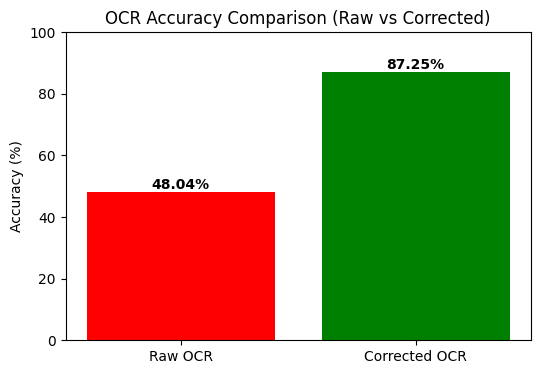

In [6]:
#Raw OCR results
raw_correct_count = 49  
raw_total_samples = 102
raw_accuracy = (raw_correct_count / raw_total_samples) * 100
#Corrected OCR results 
corrected_correct_count = 89  
corrected_total_samples = 102
corrected_accuracy = (corrected_correct_count / corrected_total_samples) * 100
print(f"Raw OCR Accuracy: {raw_accuracy:.2f}% ({raw_correct_count}/{raw_total_samples})")
print(f"Corrected OCR Accuracy: {corrected_accuracy:.2f}% ({corrected_correct_count}/{corrected_total_samples})")
plt.figure(figsize=(6, 4))
plt.bar(["Raw OCR", "Corrected OCR"], [raw_accuracy, corrected_accuracy], color=["red", "green"])
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("OCR Accuracy Comparison (Raw vs Corrected)")
for i, acc in enumerate([raw_accuracy, corrected_accuracy]):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.show()


In [8]:
easyocr_log = r"D:/My LPR project/codes_model_test_and_training/easyOCR_Implementation_log.txt"
cnn_log = r"D:/My LPR project/codes_model_test_and_training/trial_3_gui_log.txt"

#Show the line immediately after each "Filtered Plates" marker for a small sample
def sample_filtered_lists(path, max_items=8):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    results = []
    for i, line in enumerate(lines):
        if re.search(r"Filtered\s+Plates", line, re.IGNORECASE):
            # capture the next 1-2 lines as the list content
            next_line = lines[i+1].strip() if (i+1) < len(lines) else ""
            next2 = lines[i+2].strip() if (i+2) < len(lines) else ""
            results.append((line.strip(), next_line, next2))
            if len(results) >= max_items:
                break
    return results

print("=== EasyOCR samples ===")
for a,b,c in sample_filtered_lists("D:/My LPR project/codes_model_test_and_training/easyOCR_Implementation_log.txt"):
    print(a)
    print("  ->", b)
    print("  ->", c)

print("\n=== CNN samples ===")
for a,b,c in sample_filtered_lists("D:/My LPR project/codes_model_test_and_training/trial_3_gui_log.txt"):
    print(a)
    print("  ->", b)
    print("  ->", c)


=== EasyOCR samples ===
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:35,783  -
  -> 
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:35,783  -  Filtered 1: JHOICHL150
  -> 2025-08-17 17:44:35,783  -  Filtered 2: JH01CH1150
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:37,644  -  Filtered 1: JHOTES8923
  -> 2025-08-17 17:44:37,644  -  Filtered 2: JH01ES8923
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:39,493  -  Filtered 1: JHO1FCO65O
  -> 2025-08-17 17:44:39,493  -  Filtered 2: JH01FC0650
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:45,051  -  Filtered 1: JHOTBRT649
  -> 2025-08-17 17:44:45,051  -  Filtered 2: JH01BR1649
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:49,165  -
  -> 
Filtered Plates ( with valid state codes):
  -> 2025-08-17 17:44:49,165  -  Filtered 1: JHO1CE5742
  -> 2025-08-17 17:44:49,165  -  Filtered 2: JH01CE5742
Filtered Plates ( with valid state code

In [4]:
dir_path = r"D:\My LPR project\Sample Img"
def natural_key(s):
    return [ int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]
files = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))]
files.sort(key=natural_key)
for f in files:
    print(f)

24053066_car.jpg
IMG20250611193256.jpg
IMG20250611193334.jpg
IMG20250611193703.jpg
IMG20250616102412.jpg
IMG20250616102650.jpg
IMG20250616105433.jpg
IMG20250616162047.jpg
IMG20250616162056.jpg
IMG20250616162206.jpg
IMG20250617102811.jpg
IMG20250617161050.jpg
IMG20250617161122.jpg
IMG20250617162225.jpg
IMG20250617165159.jpg
IMG20250617204246.jpg
IMG20250617204450.jpg
IMG20250618161858.jpg
IMG20250618164047.jpg
IMG20250618165706.jpg
IMG20250619172559.jpg
IMG20250619172817.jpg
IMG20250619172852.jpg
IMG20250619173131.jpg
IMG20250619173431.jpg
IMG20250619173909.jpg
IMG20250619194310.jpg
IMG20250620162414.jpg
IMG20250620162802.jpg
IMG20250621160322.jpg
IMG20250623112329.jpg
IMG20250625114002.jpg
IMG20250626153454.jpg
IMG20250627125125.jpg
IMG20250627165754.jpg
IMG20250701152225.jpg
IMG20250708112358.jpg
IMG20250709151756.jpg
IMG20250711110324.jpg
IMG20250714112819.jpg
IMG20250718161101.jpg
IMG20250718170926.jpg
IMG20250718171041.jpg
IMG20250718171441.jpg
IMG20250718172140.jpg
IMG_9829.JPG
IM

In [5]:
true_values = [
    "BR01BZ3311",
    "HR26D8709",
    "KA04MN6059",
    "TS08FW3544",
    "JH02BE1579",
    "JH01FP1870",
    "JH10CC9397",
    "JH02BS8085",
    "JH10CC9397",
    "JH01A0814",
    "CG30G4387",
    "JH01FG1445",
    "OD14Z9356",
    "JH01ES7338",
    "DL12CB3478",
    "JH01CW4150",
    "JH01ES8923",
    "JH01FC0650",
    "JH01BM1649",
    "JH10CY6835",
    "JH01CE5742",
    "JH01FL7162",
    "JH01CV8618",
    "JH01FX4952",
    "JH01AB7063",
    "JH01CJ6732",
    "JH01S5001",
    "BR1U8079",
    "JH01CW0499",
    "JH01EQ6934",
    "JH01BL9208",
    "JH04E7208",
    "JH01CB0934",
    "JH01EQ6382",
    "JH01DY5433",
    "JHO1FC0394",
    "DL8CU0892",
    "JH12M9465",
    "JH01DS2498",
    "JH01BW9821",
    "JH01DH91918",
    "JH01EK4473",
    "JH01Z0688",
    "BR01CN9008",
    "AP31DO1595",
    "UP60AR6762",
    "DL14CC7320",
    "JH04R7320",
    "OD02BW0148",
    "JH05BQ4793",
    "JH01V3346",
    "DL8CBA5638",
    "JH02BG1670",
    "JH01CJ6732",
    "UK07BU0955",
    "JH01ER4274",
    "JH01BV8298",
    "UP32QP6429",
    "BR24AQ5849",
    "MH20EE7602",
    "HR26DX6666",
    "CCC444",
    "HR26BA5137",
    "RJ45CH0426",
    "RJ14CP6108",
    "UP16AD3736",
    "RJ14CF1399",
    "GJ04EE6437",
    "GJ04EE6437",
    "UP85BW1000",
    "MH20EJ0364",
    "TG109999",
    "MH14MC8285",
    "RJ192C1055",
    "MH12BG7273",
    "RJ14NC9696",
    "DL1CE1602",
    "RJ14UN4169",
    "RJ14CN5913",
    "RJ45CR5105",
    "HR26FC2782",
    "DL7CQ1939",
    "MH43CC1745",
    "LA020749",
    "KL02BM4659",
    "TN23L4574",
    "KA38M1674",
    "P03TC4945",
    "MH12DE1433",
    "MH02DS9365",
    "JH01DR8370",
    "JH01DL7680",
    "KL07CN7233",
    "JH01EU6786",
    "JH01CR2255",
    "JH01AJ9759",
    "JH01AY5570",
    "JH01BE7936",
    "JH01FC2332",
    "RJ04GB0944",
    "PB19H5569"
]

file_names = [
    "24053066_car.jpg",
    "IMG20250611193256.jpg",
    "IMG20250611193334.jpg",
    "IMG20250611193703.jpg",
    "IMG20250616102412.jpg",
    "IMG20250616102650.jpg",
    "IMG20250616105433.jpg",
    "IMG20250616162047.jpg",
    "IMG20250616162056.jpg",
    "IMG20250616162206.jpg",
    "IMG20250617102811.jpg",
    "IMG20250617161050.jpg",
    "IMG20250617161122.jpg",
    "IMG20250617162225.jpg",
    "IMG20250617165159.jpg",
    "IMG20250617204246.jpg",
    "IMG20250617204450.jpg",
    "IMG20250618161858.jpg",
    "IMG20250618164047.jpg",
    "IMG20250618165706.jpg",
    "IMG20250619172559.jpg",
    "IMG20250619172817.jpg",
    "IMG20250619172852.jpg",
    "IMG20250619173131.jpg",
    "IMG20250619173431.jpg",
    "IMG20250619173909.jpg",
    "IMG20250619194310.jpg",
    "IMG20250620162414.jpg",
    "IMG20250620162802.jpg",
    "IMG20250621160322.jpg",
    "IMG20250623112329.jpg",
    "IMG20250625114002.jpg",
    "IMG20250626153454.jpg",
    "IMG20250627125125.jpg",
    "IMG20250627165754.jpg",
    "IMG20250701152225.jpg",
    "IMG20250708112358.jpg",
    "IMG20250709151756.jpg",
    "IMG20250711110324.jpg",
    "IMG20250714112819.jpg",
    "IMG20250718161101.jpg",
    "IMG20250718170926.jpg",
    "IMG20250718171041.jpg",
    "IMG20250718171441.jpg",
    "IMG20250718172140.jpg",
    "IMG_9829.JPG",
    "IMG_20170505_165100_HDR.jpg",
    "IMG_20200522_155003.jpg",
    "IMG_20250616_162130.jpg",
    "IMG_20250616_162148.jpg",
    "IMG_20250616_162315.jpg",
    "IMG_20250620_124337.jpg",
    "IMG_20250620_124607.jpg",
    "IMG_20250620_124627.jpg",
    "IMG_20250622_152222.jpg",
    "IMG20250711_115624.jpg",
    "IMG20250715_201056.jpg",
    "IMG20250715_201951.jpg",
    "IMG20250717_141819.jpg",
    "sample0.jpg",
    "sample1.png",
    "sample2.jpg",
    "sample3.jpg",
    "sample4.jpg",
    "sample6.jpg",
    "sample7.jpg",
    "sample8.jpg",
    "sample9.jpg",
    "sample10.jpg",
    "sample11.jpg",
    "sample12.jpg",
    "sample13.png",
    "sample14.png",
    "sample15.jpg",
    "sample16.jpg",
    "sample17.jpg",
    "sample18.jpg",
    "sample19.jpg",
    "sample20.jpg",
    "sample21.jpg",
    "sample22.png",
    "sample23.png",
    "sample24.png",
    "sample25.jpg",
    "sample26.jpg",
    "sample27.jpg",
    "sample28.jpg",
    "sample29.jpg",
    "sample30.jpg",
    "sample31.jpg",
    "sample32.jpg",
    "sample33.jpg",
    "sample34.jpg",
    "sample35.jpg",
    "sample36.jpg",
    "sample37.jpg",
    "sample38.jpg",
    "sample39.jpg",
    "sample40.jpg",
    "sample41.jpg",
    "sample42.jpg"
]

mapping = dict(zip(file_names, true_values))
print(mapping)


{'24053066_car.jpg': 'BR01BZ3311', 'IMG20250611193256.jpg': 'HR26D8709', 'IMG20250611193334.jpg': 'KA04MN6059', 'IMG20250611193703.jpg': 'TS08FW3544', 'IMG20250616102412.jpg': 'JH02BE1579', 'IMG20250616102650.jpg': 'JH01FP1870', 'IMG20250616105433.jpg': 'JH10CC9397', 'IMG20250616162047.jpg': 'JH02BS8085', 'IMG20250616162056.jpg': 'JH10CC9397', 'IMG20250616162206.jpg': 'JH01A0814', 'IMG20250617102811.jpg': 'CG30G4387', 'IMG20250617161050.jpg': 'JH01FG1445', 'IMG20250617161122.jpg': 'OD14Z9356', 'IMG20250617162225.jpg': 'JH01ES7338', 'IMG20250617165159.jpg': 'DL12CB3478', 'IMG20250617204246.jpg': 'JH01CW4150', 'IMG20250617204450.jpg': 'JH01ES8923', 'IMG20250618161858.jpg': 'JH01FC0650', 'IMG20250618164047.jpg': 'JH01BM1649', 'IMG20250618165706.jpg': 'JH10CY6835', 'IMG20250619172559.jpg': 'JH01CE5742', 'IMG20250619172817.jpg': 'JH01FL7162', 'IMG20250619172852.jpg': 'JH01CV8618', 'IMG20250619173131.jpg': 'JH01FX4952', 'IMG20250619173431.jpg': 'JH01AB7063', 'IMG20250619173909.jpg': 'JH01CJ6

CNN Model -> Total: 101, Correct: 85, Accuracy: 84.16%, Errors: 16
EasyOCR -> Total: 101, Correct: 42, Accuracy: 41.58%, Errors: 37
Improvement: 42.57% (102.4% better)


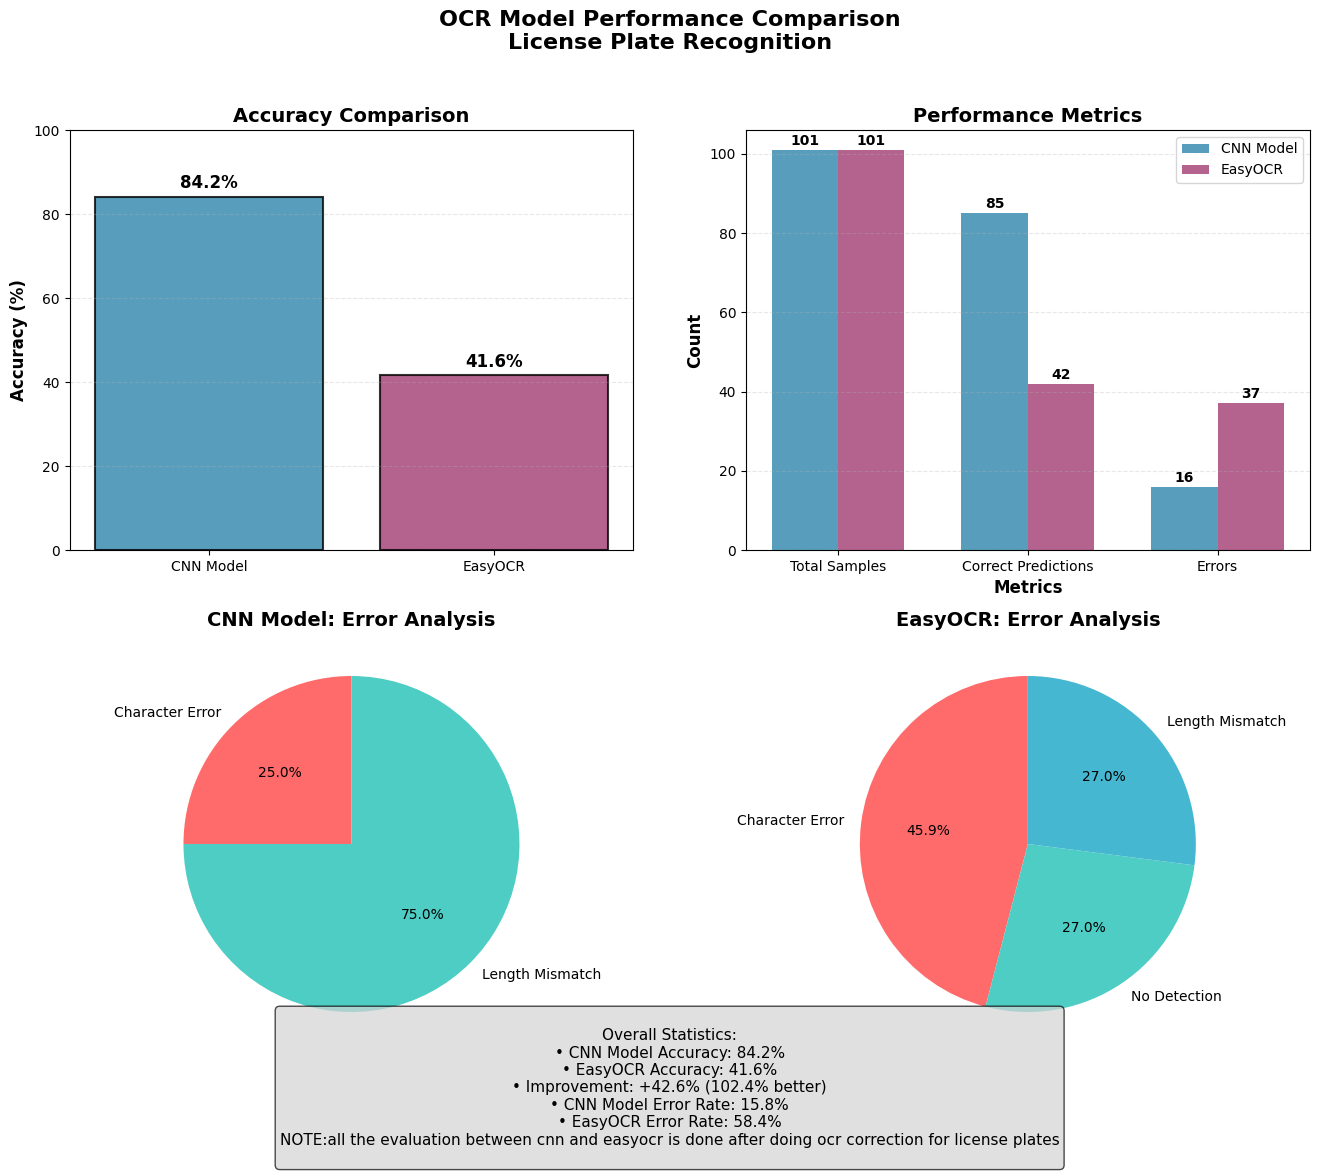


Example Errors from CNN Model:
1. Detected: 'JH10CC9397' | True: 'JH70CC9397'
2. Detected: 'JH10CC9397' | True: 'JH10CC9297'
3. Detected: 'CG30G4387' | True: 'CGOG4387'
4. Detected: 'JH01ES7338' | True: 'H01ES7338'
5. Detected: 'JH01DH91918' | True: '1H01DH9198'

Example Errors from EasyOCR:
1. Detected: 'BRO1BZ3311' | True: 'BR01BZ3311'
2. Detected: 'JHOICHL150' | True: 'JH01CW4150'
3. Detected: '(NOTHING DTEECETD)' | True: ' JH01CY6835'
4. Detected: '(NOTHING DETECTED) ' | True: ' BR1U8079'
5. Detected: '(NOTHING DETECTED)' | True: ' JH01CW0499'


In [ ]:
import matplotlib.pyplot as plt
import re
import numpy as np

##cnn
cnn_model_data = """
BR01BZ3311:Y
HR26D8709:Y
KA04MN6059:Y
TS08FW3544:Y
JH02BE1579:Y
JH01FP1870:Y
JH10CC9397:JH70CC9397
JH02BS8085:Y
JH10CC9397:JH10CC9297
JH01A0814:Y
CG30G4387:CGOG4387
JH01FG1445:Y
OD14Z9356:Y
JH01ES7338:H01ES7338
DL12CB3478:Y
JH01CW4150:Y
JH01ES8923:Y
JH01FC0650:Y
JH01BM1649:Y
JH10CY6835:Y
JH01CE5742:Y
JH01FL7162:Y
JH01CV8618:Y
JH01FX4952:Y
JH01AB7063:Y
JH01CJ6732:Y
JH01S5001:Y
BR1U8079:Y
JH01CW0499:Y
JH01EQ6934:Y
JH01BL9208:Y
JH04E7208:Y
JH01CB0934:Y
JH01EQ6382:Y
JH01DY5433:Y
JHO1FC0394:Y
DL8CU0892:Y
JH12M9465:Y
JH01DS2498:Y
JH01BW9821:Y
JH01DH91918:1H01DH9198
JH01EK4473:Y
JH01Z0688:Y
BR01CN9008:Y
AP31DO1595:Y
UP60AR6762:Y
DL14CC7320:Y
JH04R7320:Y
OD02BW0148:Y
JH05BQ4793:Y
JH01V3346:UH01V3346
DL8CBA5638:Y
JH02BG1670:Y
JH01CJ6732:Y
UK07BU0955:Y
JH01ER4274:Y
JH01BV8298:Y
UP32QP6429:Y
BR24AQ5849:Y
MH20EE7602:Y
HR26DX6666:Y
CCC444:Y
HR26BA5137:(NOTHING DETECETD)
RJ45CH0426:Y
RJ14CP6108:(FAILED TO DETCET ANY MEANINGFUL CHARACTER SEQUENCE OF A LICENSE PLATE)
UP16AD3736:UP6AD3736
RJ14CF1399:Y
GJ04EE6437:Y
GJ04EE6437:Y( FORM ANOTHER CAMERA ANGLE)
UP85BW1000:Y
MH20EJ0364:Y
TG109999:Y
MH14MC8285:Y
RJ192C1055:Y
MH12BG7273:Y
RJ14NC9696:J14NC9698
DL1CE1602:Y
RJ14UN4169:Y
RJ14CN5913:Y
RJ45CR5105:Y
HR26FC2782:Y
DL7CQ1939:Y
MH43CC1745:Y
LA020749:020749
KL02BM4659:Y
TN23L4574:KA81Z12231
KA38M1674:KA38M1674X
P03TC4945:AS881KNM01
MH12DE1433:Y
MH02DS9365:Y
JH01DR8370:Y
JH01DL7680:JH01DLV601
KL07CN7233:Y
JH01EU6786:Y
JH01CR2255:Y
JH01AJ9759:Y
JH01AY5570:Y
JH01BE7936:JH0BE7936
JH01FC2332:Y
RJ04GB0944:Y
PB19H5569:Y
"""
#easyocr
easyocr_data = """
BRO1BZ3311:BR01BZ3311
JHOICHL150:JH01CW4150
JH01ES8923:JH01ES8923
JH01FC0650:JH01FC0650
JH01BM1649:JH01BM1649
(NOTHING DTEECETD): JH01CY6835
JH01CE5742:JH01CE5742
JH01FL7162:JH01FL7162
JH01CV8618:JH01CV8618
JH01FX4952:JH01FX4952
JH01AB7063;JH01AB7063
JH01CJ6732:JH01CJ6732
JH0155001;JH01S5001
(NOTHING DETECTED) : BR1U8079
(NOTHING DETECTED): JH01CW0499
JH01EQ6934:JH01EQ6934
JH01BL9208:JH01BL9208
JH04E7208:JH04E7208
JH01CB0934:JH01CB0934
JH01E06382;JH01EQ6382
JH01DY5433:JH01DY5433
JH01FC0394:JH01FC0394
DL8CU0892:DL8CU0892
JH1209465:JH12M9465
JH01DS2198:JH01DS2498
(NOTHING DETECTED):JH01BW9821
JH01DH9198;JH01DH9198
JH01EK4413:JH01EK4413
JH01Z0688;JH01Z0688
BR01CW9008:BR01CW9008
AP31D01595:AP31DO1595
UP60AR6762:UP60AR6762
DLILCC73ZO:DL14CC7230
JH04R7320:JH04R7320
OD02BW0148:OD02BW0148
JH05BQ4793;JH05BQ4793
UHOIV3346:JH01V3346
DL8CBA5638: DL8CBA5638
JH02BG1670;JH02BG1670
JH01CJ6732;JH01CJ6732
UK07BU0955;UK07BU0955
JHOER4247:JH01ER4247
(ARCORALS):JH01BV8298
UP32QP6429;UP32QP6429
BRZLAQ5849:BR24AQ5849
KAOLMN6059:KA04MN6059
TSO8FH35LL:TS08FW3544
JH02BE1579;JH02BE1579
JH01FP1870;JH01FP1870
10CC9397:JH10CC9397
JH02BS8085:JH02BS8085
JH10CC5397:JH10CC5397
JH01A0814:JH01A0814
CG3064387:CG30G4387
(OCR DIDNT TOOK PLACE ON THE LICENSE PLATE): JH01FG1445
OD1429356:OD14Z9356
JH01ES7338:JH01ES7338
DL12CB3478:DL12CB3478
PNNATCUIN:HR26DC8709
MH20EE7602;MH20EE7602
HR26DX6666:HR26DX6666
GJ04EE6437:GJ04EE6437
UP85BH1000:UP8BW1000
MH20EJ0364;MH20EJ0364
(NOTHING DETECTED):TG109999
(NOTHIN DETECTED): MH14MC8285
RJ192C1055;RJ192C1055
MH12BG7237:MH12BG7237
RJILNC969:RJ14NC9696
DL1CE1602:DL1CE1602
RJILUNL169:RJ14UN4169
(TESLA COM): CCC444
(NOTHING DETECTED): RJ14CN5913
RJLSCR51O5:RJ45CR5105
HR26FC2782;HR26FC2782
DL7CQ1939;DL7CQ1939
MH43CC1745: MH43CC1745
L4020749;LA020749
KLOZBH4659;KL02BM4659
TN23L4547:TN23L4547
KAR8M1674:KA38M1674
P03TC4945:P03TC4945
(NOTHING DETECTED): HR26BA5137
HHI2DE1433: MH12DE1433
MH02DS9365;MH02DS9365
JH01DR8370:JH01DR8370
JH01DL7684:JH01DL7684
KL02CN7233:KL02CN7233
JH01EU6786:JH01EU6786
JH01CR2255:JH01CR2255
JH014J9759;JH014J9759
JH01AY5570:JH01AY5570
JH01BE7936;JH01BE7936
RJ45CH0426:RJ45CH0426
JH01FC2332:JH01FC2332
JO4CBO9AE:RJ04GB0944
PB1945569:PB19H5569
(NOTHING DTECETED) : RJ14CP6108
UP16AD3736:UP16AD3736
RJILCF1399: RJ14CF1399
(NOTHING DTECTECTED): GJ04EE6437
"""
def cleanText(text):
    
    #remove content in parentheses
    text = re.sub(r'\([^)]*\)', '', text)
    #remove any non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9]', '', text)
    return text.upper()

def calculate_accuracy(data_str, model_name):
    lines = [line.strip() for line in data_str.strip().split("\n") if line.strip()]
    total = len(lines)
    correct = 0
    errors = []
    
    for line in lines:
        if ":" not in line:
            continue
            
        parts = line.split(":", 1)
        if len(parts) < 2:
            continue
            
        detected = cleanText(parts[0])
        true_value = cleanText(parts[1])

        if model_name == "cnn_model":
            if true_value == "Y" and detected:
                correct += 1
            elif detected == true_value:
                correct += 1
            else:
                errors.append((parts[0], parts[1]))
        else:
            if detected == true_value:
                correct += 1
            else:
                errors.append((parts[0], parts[1]))
    
    accuracy = (correct / total) * 100 if total > 0 else 0
    return total, correct, accuracy, errors

#calculate accuracies
cnn_model_total, cnn_model_correct, cnn_model_accuracy, cnn_model_errors = calculate_accuracy(cnn_model_data, "cnn_model")
easyocr_total, easyocr_correct, easyocr_accuracy, easyocr_errors = calculate_accuracy(easyocr_data, "easyocr")

results = {
    "cnn_model": {"total": cnn_model_total, "correct": cnn_model_correct, "accuracy": cnn_model_accuracy, "errors": cnn_model_errors, "error_count": len(cnn_model_errors)},
    "easyocr": {"total": easyocr_total, "correct": easyocr_correct, "accuracy": easyocr_accuracy, "errors": easyocr_errors, "error_count": len(easyocr_errors)}
}

# Calculate additional statistics
improvement = results["cnn_model"]["accuracy"] - results["easyocr"]["accuracy"]
improvement_percentage = (improvement / results["easyocr"]["accuracy"]) * 100

print(f"CNN Model -> Total: {results['cnn_model']['total']}, Correct: {results['cnn_model']['correct']}, "
      f"Accuracy: {results['cnn_model']['accuracy']:.2f}%, Errors: {results['cnn_model']['error_count']}")
print(f"EasyOCR -> Total: {results['easyocr']['total']}, Correct: {results['easyocr']['correct']}, "
      f"Accuracy: {results['easyocr']['accuracy']:.2f}%, Errors: {results['easyocr']['error_count']}")
print(f"Improvement: {improvement:.2f}% ({improvement_percentage:.1f}% better)")

#comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
plt.suptitle('OCR Model Performance Comparison\nLicense Plate Recognition', fontsize=16, fontweight='bold', y=0.98)

#bar chart comparison
models = ['CNN Model', 'EasyOCR']
accuracies = [results['cnn_model']['accuracy'], results['easyocr']['accuracy']]
colors = ['#2E86AB', '#A23B72']

bars = ax1.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylim(0, 100)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{accuracies[i]:.1f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=12)

#performance metrics comparison
metrics = ['Total Samples', 'Correct Predictions', 'Errors']
cnn_model_metrics = [results['cnn_model']['total'], results['cnn_model']['correct'], results['cnn_model']['error_count']]
easyocr_metrics = [results['easyocr']['total'], results['easyocr']['correct'], results['easyocr']['error_count']]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax2.bar(x - width/2, cnn_model_metrics, width, label='CNN Model', color=colors[0], alpha=0.8)
bars2 = ax2.bar(x + width/2, easyocr_metrics, width, label='EasyOCR', color=colors[1], alpha=0.8)

ax2.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Performance Metrics', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')


for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{int(height)}', ha='center', va='bottom',
                 fontweight='bold')

#Error type analysis for cnn model
error_types = {}
for detected, true in results['cnn_model']['errors']:
    if detected == "Y" or "NOTHING" in detected.upper() or "FAILED" in detected.upper():
        error_type = "No Detection"
    elif len(detected) != len(true):
        error_type = "Length Mismatch"
    else:
        error_type = "Character Error"
    error_types[error_type] = error_types.get(error_type, 0) + 1

ax3.pie(error_types.values(), labels=error_types.keys(), autopct='%1.1f%%',
        startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax3.set_title('CNN Model: Error Analysis', fontsize=14, fontweight='bold')

#Error type analysis for EasyOCR
error_types_easyocr = {}
for detected, true in results['easyocr']['errors']:
    if "NOTHING" in detected.upper() or "OCR DIDNT" in detected.upper():
        error_type = "No Detection"
    elif len(detected) != len(true):
        error_type = "Length Mismatch"
    else:
        error_type = "Character Error"
    error_types_easyocr[error_type] = error_types_easyocr.get(error_type, 0) + 1

ax4.pie(error_types_easyocr.values(), labels=error_types_easyocr.keys(), autopct='%1.1f%%',
        startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax4.set_title('EasyOCR: Error Analysis', fontsize=14, fontweight='bold')

#Add overall statistics text
stats_text = f"""
Overall Statistics:
• CNN Model Accuracy: {results['cnn_model']['accuracy']:.1f}%
• EasyOCR Accuracy: {results['easyocr']['accuracy']:.1f}%
• Improvement: +{improvement:.1f}% ({improvement_percentage:.1f}% better)
• CNN Model Error Rate: {100 - results['cnn_model']['accuracy']:.1f}%
• EasyOCR Error Rate: {100 - results['easyocr']['accuracy']:.1f}%
NOTE:all the evaluation between cnn and easyocr is done after doing ocr correction for license plates
"""

plt.figtext(0.5, 0.02, stats_text, ha="center", fontsize=11, 
            bbox={"boxstyle":"round", "facecolor":"lightgray", "alpha":0.7})

#plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# Print some example errors
print("\nExample Errors from CNN Model:")
for i, (detected, true) in enumerate(results['cnn_model']['errors'][:5]):
    print(f"{i+1}. Detected: '{detected}' | True: '{true}'")

print("\nExample Errors from EasyOCR:")
for i, (detected, true) in enumerate(results['easyocr']['errors'][:5]):
    print(f"{i+1}. Detected: '{detected}' | True: '{true}'")

## TEST IMAGES AVAILABLE AT: https://dri.me/CbdGN8cJglRPSVMIpcU7nYnHPoOwA2